In [2]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
import pickle

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
# untuk ML
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# Untuk Deap Learning
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense
from tensorflow.keras.models import load_model



In [3]:
# Data Engineering

In [4]:
nltk.download('stopwords')
nltk.download('punkt')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [5]:
# Load Dataset
df = pd.read_csv('../dataset/PRDECT-ID Dataset.csv')

df_full = df.copy()

In [6]:
# Lihat isi dataset
df.head()

,Category,Product Name,Location,Price,Overall Rating,Number Sold,Total Review,Customer Rating,Customer Review,Sentiment,Emotion
0,Computers and Laptops,Wireless Keyboard i8 Mini TouchPad Mouse 2.4G ...,Jakarta Utara,53500,4.9,5449,2369,5,Alhamdulillah berfungsi dengan baik. Packaging...,Positive,Happy
1,Computers and Laptops,PAKET LISENSI WINDOWS 10 PRO DAN OFFICE 2019 O...,Kota Tangerang Selatan,72000,4.9,2359,1044,5,"barang bagus dan respon cepat, harga bersaing ...",Positive,Happy
2,Computers and Laptops,SSD Midasforce 128 Gb - Tanpa Caddy,Jakarta Barat,213000,5.0,12300,3573,5,"barang bagus, berfungsi dengan baik, seler ram...",Positive,Happy
3,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,bagus sesuai harapan penjual nya juga ramah. t...,Positive,Happy
4,Computers and Laptops,ADAPTOR CHARGER MONITOR LCD LED TV LG merek LG...,Jakarta Timur,55000,4.7,2030,672,5,"Barang Bagus, pengemasan Aman, dapat Berfungsi...",Positive,Happy


In [7]:
# Lihat jumlah data
df.shape

(5400, 11)

In [8]:
# Lihat nama kolom
df.columns

Index(['Category', 'Product Name', 'Location', 'Price', 'Overall Rating',
       'Number Sold', 'Total Review', 'Customer Rating', 'Customer Review',
       'Sentiment', 'Emotion'],
      dtype='object')

In [9]:
# Lihat info dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5400 entries, 0 to 5399
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Category         5400 non-null   object 
 1   Product Name     5400 non-null   object 
 2   Location         5400 non-null   object 
 3   Price            5400 non-null   int64  
 4   Overall Rating   5400 non-null   float64
 5   Number Sold      5400 non-null   int64  
 6   Total Review     5400 non-null   int64  
 7   Customer Rating  5400 non-null   int64  
 8   Customer Review  5400 non-null   object 
 9   Sentiment        5400 non-null   object 
 10  Emotion          5400 non-null   object 
dtypes: float64(1), int64(4), object(6)
memory usage: 464.2+ KB


In [10]:
# ambil kolom
df = df[['Customer Review', 'Sentiment']]

In [11]:
# rename kolom
df.columns = ['review', 'sentiment']

In [12]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [13]:
# Jumlah sentiment
df['sentiment'].value_counts()

sentiment
Negative    2821
Positive    2579
Name: count, dtype: int64

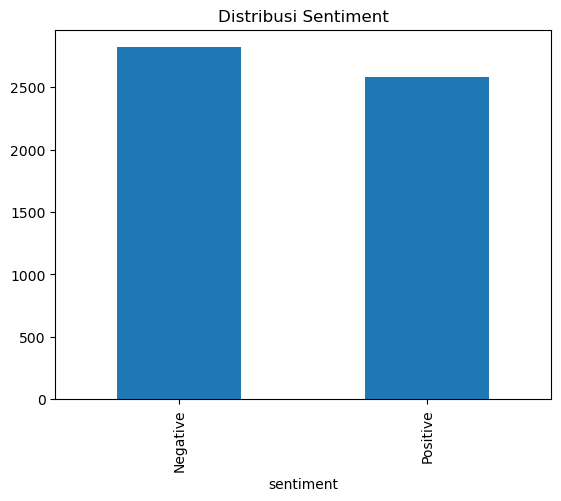

In [14]:
# Visualisasi
df['sentiment'].value_counts().plot(kind='bar')

plt.title('Distribusi Sentiment')
plt.show()

In [15]:

nltk.download('punkt_tab')

stop_words = set(stopwords.words('indonesian'))
add_words = {'yg', 'dgn', 'klo', 'bgt', 'dr', 'aja', 'admin', '.', ',','?','trimakasih'}
stop_words.update(add_words)
def clean_text(text):
    words = word_tokenize(text.lower())
    clean_words = [word for word in words if word not in stop_words]

    return ' '.join(clean_words)

[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\HP\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [16]:
# apply preprocessing
df['clean_review'] = df['review'].apply(clean_text)

# lihat hasil
pd.set_option('display.max_colwidth',None)
df[['review', 'clean_review']].head()

,review,clean_review
0,Alhamdulillah berfungsi dengan baik. Packaging aman. Respon cepat dan ramah. Seller dan kurir amanah,alhamdulillah berfungsi packaging aman respon cepat ramah seller kurir amanah
1,"barang bagus dan respon cepat, harga bersaing dengan yg lain.",barang bagus respon cepat harga bersaing
2,"barang bagus, berfungsi dengan baik, seler ramah, pengiriman cepat",barang bagus berfungsi seler ramah pengiriman cepat
3,bagus sesuai harapan penjual nya juga ramah. trimakasih pelapak ??,bagus sesuai harapan penjual nya ramah pelapak
4,"Barang Bagus, pengemasan Aman, dapat Berfungsi dengan Baik",barang bagus pengemasan aman berfungsi


In [17]:
# Tradional Machine Learning

In [18]:
# encode label
df['sentiment'] = df['sentiment'].map({
    'Positive':1,
    'Negative':0
})

In [19]:
# Hapus null
df.dropna(inplace=True)

In [20]:
# TF-IDF Vectorization
vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df['clean_review'])

y = df['sentiment']

In [21]:
# Split Data

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [22]:
# training traditional ML
model_ml = MultinomialNB()

model_ml.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [23]:
# prediksi
y_pred = model_ml.predict(X_test)

In [24]:
# Evaluasi Traditional ML
accuracy = accuracy_score(y_test, y_pred)

print('Accuracy:', accuracy)

Accuracy: 0.9055555555555556


In [25]:
# Classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.89      0.91       557
           1       0.89      0.92      0.90       523

    accuracy                           0.91      1080
   macro avg       0.91      0.91      0.91      1080
weighted avg       0.91      0.91      0.91      1080



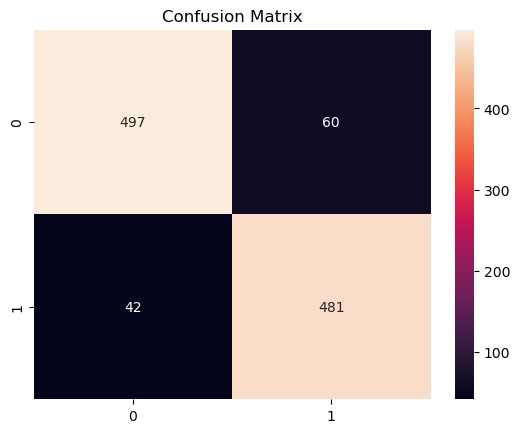

In [26]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')

plt.title('Confusion Matrix')

plt.show()

In [27]:
# Tes Manual Traditional ML
samples = [
    'barang bagus dan original',
    'pengiriman cepat dan mantap',
    'produk jelek dan rusak',
    'admin tidak respon dan mengecewakan'
]

# Vectorize
sample_vector = vectorizer.transform(samples)



In [28]:
# prediksi
predictions = model_ml.predict(sample_vector)

# tampilkan hasil
for review, pred in zip(samples, predictions):

    if pred == 1:
        sentiment = 'Positive'
    else:
        sentiment = 'Negative'

    print('Review     :', review)
    print('Prediction :', sentiment)

Review     : barang bagus dan original
Prediction : Positive
Review     : pengiriman cepat dan mantap
Prediction : Positive
Review     : produk jelek dan rusak
Prediction : Negative
Review     : admin tidak respon dan mengecewakan
Prediction : Negative


In [29]:
# Deep Learning

In [30]:
# Tokenization
tokenizer = Tokenizer(num_words=5000)

In [31]:
# belajar vocabulary
tokenizer.fit_on_texts(df['clean_review'])

In [32]:
with open('../model/tokenizer.pkl', 'wb') as handle:
    pickle.dump(tokenizer, handle)

print('Tokenizer berhasil disimpan')

Tokenizer berhasil disimpan


In [33]:

# total sentiment
print(df_full['Sentiment'].value_counts())




Sentiment
Negative    2821
Positive    2579
Name: count, dtype: int64


In [34]:
# top positive products
top_positive = (

    df_full[df_full['Sentiment'] == 'Positive']

    ['Product Name']

    .value_counts()

    .head(5)
)

print('\nTop Positive Products')
print(top_positive)


Top Positive Products
Product Name
Minigold Black Series Logam Mulia Koin Emas Mini 24 Karat 0.025 gram    25
South Korea Simcard korea selatan sim card kartu data internet Seoul    19
FULL SET BAKO BERKUALITAS AA, ALAT SLOROK BIRU - MlllLL BIASA           15
Jasa Duplikat Kartu Akses Apartemen/ Hotel - Polos                      15
Cat tembok Interior Nucolour 25 kg tidak ngapur                         15
Name: count, dtype: int64


In [35]:

# top negative products
top_negative = (

    df_full[df_full['Sentiment'] == 'Negative']

    ['Product Name']

    .value_counts()

    .head(5)
)

print('\nTop Negative Products')
print(top_negative)


Top Negative Products
Product Name
Speeds Door Chinning Bar / Pull UP bar Speeds / Iron Gym 013-4          18
Makanan kucing - Bolt Repack 1kg - Bolt Ikan                            16
Kereta Thomas Mainan Thomas                                             16
YJ-01 Nano Spray Gun Disinfectant Wireless 800 ml                       15
Mainan Anak CROCODILE DENTIST GAME / MAINAN GIGI BUAYA - GIGIT BUAYA    14
Name: count, dtype: int64


In [36]:
# Text to Sequence
X_seq = tokenizer.texts_to_sequences(df['clean_review'])

In [37]:
# Padding
X_pad = pad_sequences(X_seq, maxlen=100)

In [38]:
# split Deep Learning

X_train_dnn, X_test_dnn, y_train_dnn, y_test_dnn = train_test_split(
    X_pad,
    y,
    test_size=0.2,
    random_state=42
)

In [39]:
# Model LSTM
model_dnn = Sequential()

# Embedding layer
model_dnn.add(
    Embedding(
        input_dim=5000,
        output_dim=128,

    )
)

# LSTM layer
model_dnn.add(LSTM(128))

# Output layer
model_dnn.add(Dense(64, activation='relu'))

model_dnn.add(Dense(1, activation='sigmoid'))

# Compile model
model_dnn.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

In [40]:
history = model_dnn.fit(
    X_train_dnn,
    y_train_dnn,
    epochs=10,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 21s 148ms/step - accuracy: 0.8166 - loss: 0.4145 - val_accuracy: 0.9155 - val_loss: 0.2155
Epoch 2/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 16s 144ms/step - accuracy: 0.9436 - loss: 0.1523 - val_accuracy: 0.9167 - val_loss: 0.1854
Epoch 3/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 15s 139ms/step - accuracy: 0.9381 - loss: 0.1665 - val_accuracy: 0.9201 - val_loss: 0.2075
Epoch 4/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 15s 138ms/step - accuracy: 0.9731 - loss: 0.0708 - val_accuracy: 0.9213 - val_loss: 0.2256
Epoch 5/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 15s 141ms/step - accuracy: 0.9841 - loss: 0.0434 - val_accuracy: 0.9294 - val_loss: 0.2607
Epoch 6/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 16s 146ms/step - accuracy: 0.9852 - loss: 0.0407 - val_accuracy: 0.9190 - val_loss: 0.3175
Epoch 7/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 15s 140ms/step - accuracy: 0.9861 - loss: 0.0365 - val_accuracy: 0.9201 - val_loss: 0.2927
Epoch 8/10
108/108 ━━━━━━━━━━━━━━━━━━━━ 16s 151ms/step - accuracy: 0.9899 - loss: 0

In [41]:
# Evaluasi Deep Learning
loss, accuracy = model_dnn.evaluate(
    X_test_dnn,
    y_test_dnn
)

print('Accuracy:', accuracy)

34/34 ━━━━━━━━━━━━━━━━━━━━ 3s 60ms/step - accuracy: 0.9093 - loss: 0.4736
Accuracy: 0.9092592597007751


In [42]:


# review
samples = [
    'barang bagus dan original',
    'pengiriman cepat dan mantap',
    'produk rusak dan mengecewakan',
    'admin tidak respon dan sangat buruk'
]

for text in samples:

    # text menjadi sequence
    seq = tokenizer.texts_to_sequences([text])

    # padding
    pad = pad_sequences(seq, maxlen=100)

    # prediksi
    prediction = model_dnn.predict(pad)

    # konversi hasil sigmoid
    if prediction[0][0] > 0.5:
        sentiment = 'Positive'
    else:
        sentiment = 'Negative'

    # tampilan hasil
    print('Review     :', text)
    print('Prediction :', sentiment)
    print('Score      :', prediction[0][0])

   

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 478ms/step
Review     : barang bagus dan original
Prediction : Positive
Score      : 0.78662467
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
Review     : pengiriman cepat dan mantap
Prediction : Positive
Score      : 0.9996772
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
Review     : produk rusak dan mengecewakan
Prediction : Negative
Score      : 1.0287591e-06
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
Review     : admin tidak respon dan sangat buruk
Prediction : Negative
Score      : 1.1059971e-09


In [43]:
model_dnn.save('../model/sentiment_lstm.keras')